In [43]:
!git pull

Already up to date.


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import string


from sklearn.model_selection import train_test_split

In [45]:
%cd C:/Users/arpit/spring-2026-deep-learning-fragmented-id-resolution

C:\Users\arpit\spring-2026-deep-learning-fragmented-id-resolution


In [46]:
# Pull data/raw directory from Pedro branch
import subprocess
import os

# Extract the data/raw directory from Pedro's branch into current branch
result = subprocess.run([
    'git', 'checkout', 'origin/Pedro', '--', 'data/raw/'
], capture_output=True, text=True, check=False)

if result.returncode == 0:
    print("✓ Extracted data/raw from Pedro branch")
else:
    print(f"⚠️ Git checkout output: {result.stderr}")
    print(f"stdout: {result.stdout}")

# Verify files exist and read them
try:
    df_ncvoters = pd.read_csv(r'data/raw/ncvoters.tsv', sep='\t')
    DPL = pd.read_csv(r'data/raw/ncvoters_DPL.tsv', sep='\t')
    NDPL = pd.read_csv(r'data/raw/ncvoters_NDPL.tsv', sep='\t')
    
    print(f"✓ Loaded ncvoters from Pedro: {df_ncvoters.shape}")
    print(f"✓ Loaded DPL: {DPL.shape}")
    print(f"✓ Loaded NDPL: {NDPL.shape}")
except Exception as e:
    print(f"❌ Error loading files: {e}")


✓ Extracted data/raw from Pedro branch
✓ Loaded ncvoters from Pedro: (14183, 91)
✓ Loaded DPL: (9819, 2)
✓ Loaded NDPL: (98142, 3)


C:\Users\arpit\AppData\Local\Temp\ipykernel_61132\2713913298.py:18: DtypeWarning: Columns (59,65,89) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ncvoters = pd.read_csv(r'data/raw/ncvoters.tsv', sep='\t')


In [47]:
# Preprocessing for our fragemented ID analysis 
# Selecting identifyer variables not related to voting
df_ncvoters_frag_ID = df_ncvoters[[
#Stable Identifiers
#Only to be used for labeling /evaluation only 
# / not as a model feature
    'id', 'ncid', 'voter_reg_num', 
# Primary Model features - Strongest features, Strong entropy, Essential for matching
    #many variable such as name prefx and sufx are sparse we can either use none for missing or 0/1
    'first_name', 'midl_name', 'last_name', 'name_sufx_cd',
    #other varaiabes
# Adress Similarity features - Address is the second strongest identity anchor, 
    # Street name especially high discriminative signal # Unit numbers distinguish household
    #many variable such as unit designator are sparse we can either use none for missing or 0/1
    'house_num', 'street_name', 'street_dir', 'street_type_cd', 'unit_designator', 'unit_num', 'zip_code', 'res_city_desc',
#other varaiabes
# Demographic agreement indicators - Moderate/Supporting Features 
    # these will help us reduce false matches # they are agreement indicators, low-weight similarity features
    #age group rather than age because grouped/bin age is more stable
    'age', 'age_group', 'sex', 'race_code', 'race_desc', 'ethnic_code', 'ethnic_desc', 'birth_place',
# #other varaiabes 
 'phone_num','area_cd'   
 ]]
# print("\nSelected variables 'A' and 'C':")
print(df_ncvoters_frag_ID)

             id      ncid  voter_reg_num first_name  midl_name   last_name  \
0           277  aa173006        9132930  domenique       anna   gramolini   
1           566  aa175613        9136375    deborah                  wells   
2          1369  aa188072        9155533       evan  nathaniel     workman   
3          1567  by580879        9157283     alyssa   danielle      marion   
4          1583   ax51253        9157299    lacosta       gail  williamson   
...         ...       ...            ...        ...        ...         ...   
14178  14181892   er19108          19163     jerome     wilson      crouse   
14179  14182849  bn333629          71381      james    richard      dayton   
14180  14183213   en51685          77917       noah    matthew      pardue   
14181  14183530   er32617          62638     krista    stanley  williamson   
14182  14183738   er30307          60328      chara       lane    o connor   

      name_sufx_cd  house_num           street_name street_dir 

In [48]:
# Adding labels to DPL and NDPL
DPL['label'] = 1 
NDPL['label'] = 0


print(DPL.head(10))
print(NDPL.head(10))

        id1      id2  label
0  11401396   511079      1
1   3569312  9442163      1
2   3569312  9522852      1
3   3569312  9549525      1
4   9442163  9522852      1
5   9442163  9549525      1
6   9522852  9549525      1
7  12658910  3213055      1
8  12658910  3174121      1
9   3213055  3174121      1
        id1       id2  participation  label
0  11826037   3981077       0.428571      0
1  11914983   2089120       0.428571      0
2  10063200  14074062       0.428571      0
3  13740661  13779277       0.428571      0
4  12909240  12927497       0.428571      0
5  12496955  12523473       0.428571      0
6  10378846  10400866       0.428571      0
7  13145288   9989193       0.285714      0
8   9760941   9976890       0.285714      0
9   1027663    997075       0.285714      0


In [49]:
#Merge Duplicate and Non Duplicate pairs
pairs = pd.concat([DPL, NDPL])

print(pairs.head(20))
print(pairs.tail(20))


         id1       id2  label  participation
0   11401396    511079      1            NaN
1    3569312   9442163      1            NaN
2    3569312   9522852      1            NaN
3    3569312   9549525      1            NaN
4    9442163   9522852      1            NaN
5    9442163   9549525      1            NaN
6    9522852   9549525      1            NaN
7   12658910   3213055      1            NaN
8   12658910   3174121      1            NaN
9    3213055   3174121      1            NaN
10   1033927   9114975      1            NaN
11   8655919    847046      1            NaN
12   3462484  10261176      1            NaN
13    383933   7826253      1            NaN
14   7092750   7022921      1            NaN
15   1658211   6300974      1            NaN
16   9167292    377059      1            NaN
17  13224692   3594362      1            NaN
18    222684   3714715      1            NaN
19    299592   9279844      1            NaN
            id1       id2  label  participation
98122  

In [50]:
# merging ncvoters on DPL and NDPL
pairs = pairs.merge(
    df_ncvoters_frag_ID,
    left_on="id1",
    right_on="id",
    how="left"
)
print(pairs.info())
print(pairs.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107961 entries, 0 to 107960
Data columns (total 29 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id1              107961 non-null  int64  
 1   id2              107961 non-null  int64  
 2   label            107961 non-null  int64  
 3   participation    98142 non-null   float64
 4   id               107961 non-null  int64  
 5   ncid             107961 non-null  object 
 6   voter_reg_num    107961 non-null  int64  
 7   first_name       107961 non-null  object 
 8   midl_name        107961 non-null  object 
 9   last_name        107961 non-null  object 
 10  name_sufx_cd     107961 non-null  object 
 11  house_num        107961 non-null  int64  
 12  street_name      107961 non-null  object 
 13  street_dir       107961 non-null  object 
 14  street_type_cd   107961 non-null  object 
 15  unit_designator  107961 non-null  object 
 16  unit_num         107961 non-null  obje

In [51]:
#merging id2 
pairs = pairs.merge(
    df_ncvoters_frag_ID,
    left_on="id2",
    right_on="id",
    how="left",
    suffixes=("_1", "_2")
)

print(pairs.info())
print(pairs.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107961 entries, 0 to 107960
Data columns (total 54 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id1                107961 non-null  int64  
 1   id2                107961 non-null  int64  
 2   label              107961 non-null  int64  
 3   participation      98142 non-null   float64
 4   id_1               107961 non-null  int64  
 5   ncid_1             107961 non-null  object 
 6   voter_reg_num_1    107961 non-null  int64  
 7   first_name_1       107961 non-null  object 
 8   midl_name_1        107961 non-null  object 
 9   last_name_1        107961 non-null  object 
 10  name_sufx_cd_1     107961 non-null  object 
 11  house_num_1        107961 non-null  int64  
 12  street_name_1      107961 non-null  object 
 13  street_dir_1       107961 non-null  object 
 14  street_type_cd_1   107961 non-null  object 
 15  unit_designator_1  107961 non-null  object 
 16  un

Train Test Val Split

In [52]:
import networkx as nx
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split 

# only duplicates
dup_pairs = pairs[pairs["label"] == 1]

G = nx.Graph()

# add edges
G.add_edges_from(zip(dup_pairs["id1"], dup_pairs["id2"]))

# connected components = entity clusters
components = list(nx.connected_components(G))

In [53]:
# Adding ids back in data 

all_ids = set(df_ncvoters_frag_ID["id"])
ids_in_graph = set(G.nodes())

singletons = all_ids - ids_in_graph

for s in singletons:
    components.append({s})

In [54]:
# Split

train_groups, temp_groups = train_test_split(
    components,
    test_size=0.3,
    random_state=42
)

val_groups, test_groups = train_test_split(
    temp_groups,
    test_size=0.5,
    random_state=42
)

In [55]:
#Converting groups to ids 
train_ids = set().union(*train_groups)
val_ids   = set().union(*val_groups)
test_ids  = set().union(*test_groups)

In [56]:
#bringing dups and non dups together

train_pairs = pairs[pairs["id1"].isin(train_ids) & pairs["id2"].isin(train_ids)]

val_pairs = pairs[pairs["id1"].isin(val_ids) & pairs["id2"].isin(val_ids)]

test_pairs = pairs[pairs["id1"].isin(test_ids) & pairs["id2"].isin(test_ids)]

In [57]:
print("Train:", len(train_pairs))
print("Val:", len(val_pairs))
print("Test:", len(test_pairs))

Train: 54677
Val: 3573
Test: 3870


In [58]:
print(df_ncvoters_frag_ID.columns)
print(pairs.columns)

print(train_pairs.columns)
print(val_pairs.columns)
print(test_pairs.columns)

Index(['id', 'ncid', 'voter_reg_num', 'first_name', 'midl_name', 'last_name',
       'name_sufx_cd', 'house_num', 'street_name', 'street_dir',
       'street_type_cd', 'unit_designator', 'unit_num', 'zip_code',
       'res_city_desc', 'age', 'age_group', 'sex', 'race_code', 'race_desc',
       'ethnic_code', 'ethnic_desc', 'birth_place', 'phone_num', 'area_cd'],
      dtype='object')
Index(['id1', 'id2', 'label', 'participation', 'id_1', 'ncid_1',
       'voter_reg_num_1', 'first_name_1', 'midl_name_1', 'last_name_1',
       'name_sufx_cd_1', 'house_num_1', 'street_name_1', 'street_dir_1',
       'street_type_cd_1', 'unit_designator_1', 'unit_num_1', 'zip_code_1',
       'res_city_desc_1', 'age_1', 'age_group_1', 'sex_1', 'race_code_1',
       'race_desc_1', 'ethnic_code_1', 'ethnic_desc_1', 'birth_place_1',
       'phone_num_1', 'area_cd_1', 'id_2', 'ncid_2', 'voter_reg_num_2',
       'first_name_2', 'midl_name_2', 'last_name_2', 'name_sufx_cd_2',
       'house_num_2', 'street_name_2'



 Augmented positives
 +  typos
  + nicknames
  + address abbreviation

 Hard negatives
  + same household
  + same same lastname
  + same firstname
  + suffix

Medium negative 
  + same first name negative  

Positives
  + same household
  + original duplicates
  +	typo duplicates
  + nickname duplicates
  + street abbreviation duplicates
  + multi-field duplicates

Negatives
 + household pairs
 + nickname negatives
 + suffix negatives
 + address formatting negatives


In [59]:
#Creating a new variable id_to_clusters to be used in augmented training cell - #4 household negatives 
id_to_cluster = {}
for cluster_id, component in enumerate(components):
    for voter_id in component:
        id_to_cluster[voter_id] = cluster_id

# singletons
next_id = len(components)
for v_id in df_ncvoters_frag_ID["id"]:
    if v_id not in id_to_cluster:
        id_to_cluster[v_id] = next_id
        next_id += 1

print(f"Total IDs mapped: {len(id_to_cluster)}")

Total IDs mapped: 14183


In [60]:
# 1. Utilities (names + street logic)

import random

nickname_dict = {
    "william": ["bill","billy","will"],
    "robert": ["bob","bobby","rob"],
    "james": ["jim","jimmy"],
    "john": ["jack","johnny"],
    "elizabeth": ["liz","beth","lizzy"],
    "margaret": ["maggie","meg","peggy"],
    "katherine": ["kate","kathy"],
    "sarah": ["sara"]
}

street_expand = {
    "st":"street",
    "rd":"road",
    "ave":"avenue",
    "dr":"drive",
    "ln":"lane",
    "blvd":"boulevard"
}

def nickname(name):
    n = str(name).lower()
    if n in nickname_dict:
        return random.choice(nickname_dict[n])
    for k,v in nickname_dict.items():
        if n in v:
            return k
    return name


def typo(name):
    name=list(str(name))
    if len(name)<3:
        return "".join(name)
    i=random.randint(0,len(name)-2)
    name[i],name[i+1]=name[i+1],name[i]
    return "".join(name)


def expand_street(st):
    s=str(st).lower()
    return street_expand.get(s,s)

    

In [61]:

# 2. Duplicate augmentation (label = 1) - This creates multi-field realistic duplicates.

def augment_duplicates(train_pairs):
    augmented = []
    for _, row in train_pairs.iterrows():
        if row["label"] != 1:
            continue
        r = row.copy()
        side1_changed = False
        side2_changed = False

        if random.random() < 0.4:
            if random.random() < 0.5:
                r["first_name_1"] = typo(r["first_name_1"])
                side1_changed = True
            else:
                r["first_name_2"] = typo(r["first_name_2"])
                side2_changed = True

        if random.random() < 0.25:
            if not side1_changed and random.random() < 0.5:
                r["first_name_1"] = nickname(r["first_name_1"])
                side1_changed = True
            elif not side2_changed:
                r["first_name_2"] = nickname(r["first_name_2"])
                side2_changed = True

        if random.random() < 0.25:
            if not side1_changed:
                r["street_type_cd_1"] = expand_street(r["street_type_cd_1"])
            elif not side2_changed:
                r["street_type_cd_2"] = expand_street(r["street_type_cd_2"])

        augmented.append(r)
    return pd.DataFrame(augmented)

#aug_dups2 = augment_duplicates(train_pairs)
aug_dups2 = augment_duplicates(train_pairs)
print(aug_dups2.shape)
print(aug_dups2["first_name_1"].head())
print(train_pairs[train_pairs["label"]==1]["first_name_1"].head())

(6826, 54)
0       erci
1    semaje 
2    semaje 
3    semaje 
4     asmaje
Name: first_name_1, dtype: object
0       eric
1    semaje 
2    semaje 
3    semaje 
4     samaje
Name: first_name_1, dtype: object


In [62]:
#3 adding steert_ type expansion in both direction 

def street_type_negatives(train_pairs, n=2000):
    pairs = []
    for _, row in train_pairs.sample(len(train_pairs)).iterrows():
        if row["label"] == 1:
            continue
        # skip if both street types are empty
        if row["street_type_cd_1"] == "" and row["street_type_cd_2"] == "":
            continue
        r = row.copy()
        if random.random() < 0.5:
            r["street_type_cd_1"] = expand_street(r["street_type_cd_1"])
        else:
            r["street_type_cd_2"] = expand_street(r["street_type_cd_2"])
        if r["street_type_cd_1"] != row["street_type_cd_1"] or \
           r["street_type_cd_2"] != row["street_type_cd_2"]:
            r["label"] = 0
            pairs.append(r)
        if len(pairs) >= n:
            break
    return pd.DataFrame(pairs)

In [63]:
# ####We wanted: different people, same address --> confusing negative
#Reality:   same address → almost always same person in this dataset


# household_negatives isn't a useful hard negative generator for this specific dataset.
#  # 4. Hard negatives - We generate confusing but non-duplicate pairs. 
# # Household negatives (same address)
# # since this is being generated, I want to make sure to not accidentally append a known duplicate - cluster saftey
# def household_negatives(train_pairs,cluster_map, n=3000):

#     pairs=[]

#     groups=train_pairs.groupby(
#         ["house_num_1","street_name_1"]
#     )

#     for _,g in groups:

#         if len(g)<2:
#             continue

#         sample=g.sample(min(len(g),2))

#         r=sample.iloc[0].copy()

#         #cluster saftey check 
#         if cluster_map.get(sample.iloc[0]["id1"]) == cluster_map.get(sample.iloc[1]["id1"]):
#             continue

#         r["first_name_2"]=sample.iloc[1]["first_name_1"]
#         r["last_name_2"]=sample.iloc[1]["last_name_1"]

#         r["label"]=0
        

#         pairs.append(r)

#         if len(pairs)>=n:
#             break

#     return pd.DataFrame(pairs)

In [64]:
#5 Nickname negatives 
#this simply adds nickname negatives by swapping some first names to nick names in the NDPL

def nickname_negatives(train_pairs,n=2000):

    pairs=[]

    for _,row in train_pairs.sample(len(train_pairs)).iterrows():
        if row["label"]==1: 
            continue

        r=row.copy()

        r["first_name_2"]=nickname(r["first_name_2"])

        if r["first_name_2"]!=row["first_name_2"]:

            r["label"]=0
            pairs.append(r)

        if len(pairs)>=n:
            break

    return pd.DataFrame(pairs)

In [65]:
# # Suffix negatives Jr/Sr) - 0 in the negative data so this is meaningless it just would add noise and not signal 
# There 124 dups with suffixes — they're valid duplicates where one record has a missing suffix 
# #generating nonsensical suffix 
# def suffix_negatives(train_pairs,n=1000):

#     pairs=[]

#     for _,row in train_pairs.iterrows():
#          if row["label"] == 1:  # skip duplicates, work from negatives
#             continue
#         r=row.copy()

#         if pd.notna(row["name_sufx_cd_1"]):

#             r["name_sufx_cd_2"]="jr" if row["name_sufx_cd_1"]!="jr" else "sr"
#             r["label"]=0

#             pairs.append(r)

#         if len(pairs)>=n:
#             break

#     return pd.DataFrame(pairs)



Tested Suffix and it looks like it doesn't make sense to generate negative suffixes. 
* Because only dups would have junior-senior pairs. 
* could have non dups that are junior singleton and senior singleton. 
* the occurences of suffixes are sparse in our data
* we have 124 duplicate pairs with suffix mismatch -> valid raw data 

In [66]:
# # Checking for confusable suffix cases in negatives
# confusable_negs = train_pairs[
#     (train_pairs["label"] == 0) &
#     (train_pairs["first_name_1"] == train_pairs["first_name_2"]) &
#     (train_pairs["last_name_1"] == train_pairs["last_name_2"]) &
#     (train_pairs["name_sufx_cd_1"] != train_pairs["name_sufx_cd_2"])
# ].shape[0]

# # Check confusable suffix cases in duplicates
# confusable_dups = train_pairs[
#     (train_pairs["label"] == 1) &
#     (train_pairs["first_name_1"] == train_pairs["first_name_2"]) &
#     (train_pairs["last_name_1"] == train_pairs["last_name_2"]) &
#     (train_pairs["name_sufx_cd_1"] != train_pairs["name_sufx_cd_2"])
# ].shape[0]

# print(f"Confusable suffix negatives: {confusable_negs}")
# print(f"Confusable suffix duplicates: {confusable_dups}")

# # Check how common suffixes are overall
# print(f"\nSuffix value counts id1:\n{train_pairs['name_sufx_cd_1'].value_counts()}")
# print(f"\nSuffix value counts id2:\n{train_pairs['name_sufx_cd_2'].value_counts()}")

In [67]:
# #how many are missing suffixes on one side?
# # Verify - how many are just missing suffix on one side
# missing_one_side = suspicious[
#     (suspicious["name_sufx_cd_1"] == "") | 
#     (suspicious["name_sufx_cd_2"] == "")
# ].shape[0]

# actual_conflict = suspicious[
#     (suspicious["name_sufx_cd_1"] != "") & 
#     (suspicious["name_sufx_cd_2"] != "") &
#     (suspicious["name_sufx_cd_1"] != suspicious["name_sufx_cd_2"])
# ].shape[0]

# print(f"Missing suffix on one side: {missing_one_side}")
# print(f"Actual SR/JR conflicts: {actual_conflict}")

In [68]:
# augmented training set 
aug_dups = augment_duplicates(train_pairs)

# hard 
street_neg = street_type_negatives(train_pairs)
#household_neg = household_negatives(train_pairs, id_to_cluster)
nickname_neg = nickname_negatives(train_pairs)

train_pairs_aug = pd.concat(
    [train_pairs,
     aug_dups, 
     street_neg,
    #household_neg, 
     nickname_neg],
    ignore_index=True
)

In [ ]:
#adding augmentation to val and test splits 
def augment_split(pairs):
    aug = augment_duplicates(pairs)
    street = street_type_negatives(pairs)
    nick = nickname_negatives(pairs)
    
    return pd.concat(
        [pairs, aug, street, nick],
        ignore_index=True
    )

# Apply consistently across all splits
train_pairs_aug = augment_split(train_pairs)
val_pairs_aug   = augment_split(val_pairs)
test_pairs_aug  = augment_split(test_pairs)

Checking that all augmentations and hard negatives changes worked on TRAINING SET 

In [146]:
# 1. Typo check - first_name should differ from original
typo_changes = aug_dups2[aug_dups2["first_name_1"] != train_pairs.loc[aug_dups2.index, "first_name_1"].values]
print(f"Typo applied to first_name_1: {len(typo_changes)}")

typo_changes2 = aug_dups2[aug_dups2["first_name_2"] != train_pairs.loc[aug_dups2.index, "first_name_2"].values]
print(f"Typo applied to first_name_2: {len(typo_changes2)}")

# 2. Nickname check - first_name should be in nickname dict values
nickname_changes1 = aug_dups2[aug_dups2["first_name_1"].str.lower().isin(
    [n for names in nickname_dict.values() for n in names] + list(nickname_dict.keys())
)]
print(f"Nickname in first_name_1: {len(nickname_changes1)}")

nickname_changes2 = aug_dups2[aug_dups2["first_name_2"].str.lower().isin(
    [n for names in nickname_dict.values() for n in names] + list(nickname_dict.keys())
)]
print(f"Nickname in first_name_2: {len(nickname_changes2)}")

# 3. Street expansion check - should see full words not abbreviations
expanded1 = aug_dups2[aug_dups2["street_type_cd_1"].isin(street_expand.values())]
print(f"Street expanded in street_type_cd_1: {len(expanded1)}")

expanded2 = aug_dups2[aug_dups2["street_type_cd_2"].isin(street_expand.values())]
print(f"Street expanded in street_type_cd_2: {len(expanded2)}")

# 4. Nickname negatives check
nick_negs = train_pairs_aug[
    (train_pairs_aug["label"] == 0) &
    (train_pairs_aug["first_name_2"].str.lower().isin(
        [n for names in nickname_dict.values() for n in names]
    ))
]
print(f"Nickname negatives: {len(nick_negs)}")

# 5. Street type negatives check
street_negs = train_pairs_aug[
    (train_pairs_aug["label"] == 0) &
    (train_pairs_aug["street_type_cd_1"].isin(street_expand.values()) |
     train_pairs_aug["street_type_cd_2"].isin(street_expand.values()))
]
print(f"Street type negatives: {len(street_negs)}")

# # 6. Household negatives check
# household_negs = train_pairs_aug[
#     (train_pairs_aug["label"] == 0) &
#     (train_pairs_aug["house_num_1"] == train_pairs_aug["house_num_2"]) &
#     (train_pairs_aug["street_name_1"] == train_pairs_aug["street_name_2"])
# ]
# print(f"Household negatives: {len(household_negs)}")

# 7. Overall label distribution
counts = train_pairs_aug["label"].value_counts()
pcts = train_pairs_aug["label"].value_counts(normalize=True) * 100
print(pd.DataFrame({"count": counts, "percentage": pcts.round(2)}))

Typo applied to first_name_1: 1337
Typo applied to first_name_2: 1420
Nickname in first_name_1: 446
Nickname in first_name_2: 441
Street expanded in street_type_cd_1: 929
Street expanded in street_type_cd_2: 289
Nickname negatives: 2306
Street type negatives: 2000
       count  percentage
label                   
0      51851       79.16
1      13652       20.84


In [71]:
#How hard are our negatives?

# Check nickname negatives - how often do names match after nickname swap
nick_neg_rows = train_pairs_aug[
    (train_pairs_aug["label"] == 0) &
    (train_pairs_aug["first_name_2"].str.lower().isin(
        [n for names in nickname_dict.values() for n in names]
    ))
]

# How many have same last name - harder if last name also matches
same_last = (nick_neg_rows["last_name_1"] == nick_neg_rows["last_name_2"]).sum()
diff_last = (nick_neg_rows["last_name_1"] != nick_neg_rows["last_name_2"]).sum()

print(f"Nickname negatives with same last name: {same_last} ({same_last/len(nick_neg_rows)*100:.1f}%)")
print(f"Nickname negatives with different last name: {diff_last} ({diff_last/len(nick_neg_rows)*100:.1f}%)")

# Street negatives hardness
street_neg_rows = train_pairs_aug[
    (train_pairs_aug["label"] == 0) &
    (train_pairs_aug["street_type_cd_1"].isin(street_expand.values()) |
     train_pairs_aug["street_type_cd_2"].isin(street_expand.values()))
]

same_name = (
    (street_neg_rows["first_name_1"] == street_neg_rows["first_name_2"]) &
    (street_neg_rows["last_name_1"] == street_neg_rows["last_name_2"])
).sum()

print(f"\nStreet negatives with same full name: {same_name} ({same_name/len(street_neg_rows)*100:.1f}%)")

Nickname negatives with same last name: 11 (0.5%)
Nickname negatives with different last name: 2295 (99.5%)

Street negatives with same full name: 0 (0.0%)


In [72]:
# do truly hard negatives even EXIST in our data? No

# Same last name + nickname first name pairs from different clusters
truly_hard = train_pairs[
    (train_pairs["label"] == 0) &
    (train_pairs["last_name_1"] == train_pairs["last_name_2"]) &
    (train_pairs["first_name_1"].str.lower().isin(nickname_dict.keys())) &
    (train_pairs["first_name_2"].str.lower().isin(
        [n for names in nickname_dict.values() for n in names]
    ))
]
print(f"Truly hard nickname negatives available: {len(truly_hard)}")

Truly hard nickname negatives available: 1


What actually differ in real duplicates 

* first_name: 139 differ (2.0%) <- almost never differs
* last_name: 965 differ (14.1%) <- Secondary signal 
* house_num: 6230 differ (91.3%)  <- Primary fragmentation signal 
* street_name: 6203 differ (90.9%) <- Primary fragmentation signal 
* street_type_cd: 5082 differ (74.5%) <- Stron signal

This tells us what we knew already from the EDA 
* duplicates in our dataset are primarily people who moved — same person, different address.
* and name changes (marraige, divorce) is a secondary signal


Our baseline features should heavily weight name similarity and treat address as a weak or noisy signal rather than a strong one. The fragmented ID problem in this dataset is fundamentally an address change detection problem, not a name variation problem. 



In [73]:
# What actually differs between real duplicates
orig_dups = train_pairs[train_pairs["label"] == 1]
cols = ["first_name", "last_name", "house_num", "street_name", "street_type_cd"]

for col in cols:
    diff = (orig_dups[f"{col}_1"] != orig_dups[f"{col}_2"]).sum()
    pct = diff / len(orig_dups) * 100
    print(f"{col}: {diff} differ ({pct:.1f}%)")

first_name: 139 differ (2.0%)
last_name: 965 differ (14.1%)
house_num: 6230 differ (91.3%)
street_name: 6203 differ (90.9%)
street_type_cd: 5082 differ (74.5%)


In [74]:
# # Check how many household pairs get rejected by cluster safety check
# groups = train_pairs.groupby(["house_num_1","street_name_1"])
# rejected = 0
# eligible = 0

# for _, g in groups:
#     if len(g) < 2:
#         continue
#     sample = g.sample(min(len(g), 2))
#     eligible += 1
#     if id_to_cluster.get(sample.iloc[0]["id1"]) == id_to_cluster.get(sample.iloc[1]["id1"]):
#         rejected += 1

# print(f"Eligible groups: {eligible}")
# print(f"Rejected by cluster safety check: {rejected}")
# print(f"Passed: {eligible - rejected}")

In [75]:
# viewing augmentation results to make 
cols=[
"first_name_1","first_name_2",
"last_name_1","last_name_2",
"house_num_1","house_num_2",
"street_name_1","street_name_2",
"street_type_cd_1","street_type_cd_2",
"label" #, "age"
]

train_pairs_aug[cols].sample(40)

,first_name_1,first_name_2,last_name_1,last_name_2,house_num_1,house_num_2,street_name_1,street_name_2,street_type_cd_1,street_type_cd_2,label
19285,gregory,frances,stackhouse,faison,688,9117,thompson town,meadow vista,rd,rd,0
38137,elizabeth,bethany,mays,gilmore,10545,1400,nc hwy 105,cornwallis,,rd,0
59438,arnt,anrt,sundseth,sundseth,1140,4701,juniper,abbotts creek church,rd,rd,1
29339,anthony,julie,pope,pittman,18,1012,church,neuse ridge,rd,dr,0
3872,john,john,fath,fath,2201,4105,foxhorn,kenan,rd,ct,1
6351,sharon,sharon,napier,napier thompson,8918,1510,millers bend,hornes church,,rd,1
37112,carolyn,mary,parker,tucker,1880,107,mill pond,cape fear,rd,dr,0
15738,benjamin,christina,dockey,franklin,5220,5853,fair wind,cold springs lodge,ln,,0
56815,charles,charlse,ward,ward,8420,426,fazio,hilltop view,dr,st,1
37960,anthony,courtney,millwood,scott,1237,1508,long branch,woodway club,rd,dr,0


In [76]:
#Checking for nonesensical dups
train_pairs[train_pairs.label==1][
["first_name_1","first_name_2","last_name_1","last_name_2"]
].sample(40)

,first_name_1,first_name_2,last_name_1,last_name_2
8248,david,david,furman,furman
1641,travoye,travoye,mccray,mccray
5224,sean,sean,safrit,safrit
2152,frances,frances,patterson,patterson
2871,darryl,darryl,moye,moye
1750,carey,carey,west,west
5066,christina,christina,wilson,wilson
3121,jennifer,jennifer,wilson,wilson
1603,naomia,naomia,harris,harris
2325,charles,charles,murdock,murdock


In [77]:
# Check all columns are present in augmented data
print(aug_dups.columns.tolist())

# Spot check - view all fields for a few augmented records
aug_dups.sample(5).T  # .T transposes to see all fields vertically

['id1', 'id2', 'label', 'participation', 'id_1', 'ncid_1', 'voter_reg_num_1', 'first_name_1', 'midl_name_1', 'last_name_1', 'name_sufx_cd_1', 'house_num_1', 'street_name_1', 'street_dir_1', 'street_type_cd_1', 'unit_designator_1', 'unit_num_1', 'zip_code_1', 'res_city_desc_1', 'age_1', 'age_group_1', 'sex_1', 'race_code_1', 'race_desc_1', 'ethnic_code_1', 'ethnic_desc_1', 'birth_place_1', 'phone_num_1', 'area_cd_1', 'id_2', 'ncid_2', 'voter_reg_num_2', 'first_name_2', 'midl_name_2', 'last_name_2', 'name_sufx_cd_2', 'house_num_2', 'street_name_2', 'street_dir_2', 'street_type_cd_2', 'unit_designator_2', 'unit_num_2', 'zip_code_2', 'res_city_desc_2', 'age_2', 'age_group_2', 'sex_2', 'race_code_2', 'race_desc_2', 'ethnic_code_2', 'ethnic_desc_2', 'birth_place_2', 'phone_num_2', 'area_cd_2']


,7784,5204,258,5731,6649
id1,8332592,7310429,10169103,544480,8550243
id2,8347468,13537027,9537915,602002,950894
label,1,1,1,1,1
participation,NaN,NaN,NaN,NaN,NaN
id_1,8332592,7310429,10169103,544480,8550243
ncid_1,cw943048,eh857607,dd78297,al199140,cw76318
voter_reg_num_1,1000073541,25618,103570,228636,321955
first_name_1,isabelle,george,david,kira,gordon
midl_name_1,kelly,hilden,james,agnette,alexander
last_name_1,voler,gensic,revell,greco,edwards


In [ ]:
#applying across splits 
def augment_split(pairs):
    aug = augment_duplicates(pairs)
    street = street_type_negatives(pairs)
    nick = nickname_negatives(pairs)
    
    return pd.concat(
        [pairs, aug, street, nick],
        ignore_index=True
    )

# Apply consistently across all splits
train_pairs_aug = augment_split(train_pairs)
val_pairs_aug   = augment_split(val_pairs)
test_pairs_aug  = augment_split(test_pairs)

Testing

In [134]:
!pip install jellyfish

In [135]:
from jellyfish import jaro_winkler_similarity

def build_features(pairs):
    features = pd.DataFrame()
    
    features["first_name_sim"] = pairs.apply(
        lambda r: jaro_winkler_similarity(
            str(r["first_name_1"]).lower(), 
            str(r["first_name_2"]).lower()
        ), axis=1
    )
    features["last_name_sim"] = pairs.apply(
        lambda r: jaro_winkler_similarity(
            str(r["last_name_1"]).lower(), 
            str(r["last_name_2"]).lower()
        ), axis=1
    )
    
    features["house_num_match"] = (pairs["house_num_1"] == pairs["house_num_2"]).astype(int)
    features["street_name_sim"] = pairs.apply(
        lambda r: jaro_winkler_similarity(
            str(r["street_name_1"]).lower(),
            str(r["street_name_2"]).lower()
        ), axis=1
    )
    features["street_type_match"] = (pairs["street_type_cd_1"] == pairs["street_type_cd_2"]).astype(int)
    
    return features

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train = build_features(train_pairs_aug)
y_train = train_pairs_aug["label"]

X_val = build_features(val_pairs_aug)
y_val = val_pairs_aug["label"]

# X_test = build_features(test_pairs_aug)
# y_test = test_pairs_aug["label"]

model = LogisticRegression()
model.fit(X_train, y_train)

print("Val results:")
print(classification_report(y_val, model.predict(X_val)))

# print("Test results:")
# print(classification_report(y_test, model.predict(X_test)))

Val results:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      3999
           1       0.98      0.96      0.97      2938

    accuracy                           0.97      6937
   macro avg       0.97      0.97      0.97      6937
weighted avg       0.97      0.97      0.97      6937



In [82]:
# from jellyfish import jaro_winkler_similarity

# def build_features(pairs):
#     features = pd.DataFrame()
    
#     # Name similarity - primary signal (almost never differs in real dups)
#     features["first_name_sim"] = pairs.apply(
#         lambda r: jaro_winkler_similarity(
#             str(r["first_name_1"]).lower(), 
#             str(r["first_name_2"]).lower()
#         ), axis=1
#     )
#     features["last_name_sim"] = pairs.apply(
#         lambda r: jaro_winkler_similarity(
#             str(r["last_name_1"]).lower(), 
#             str(r["last_name_2"]).lower()
#         ), axis=1
#     )
    
#     # Address similarity - noisy signal (91% differ in real dups)
#     features["house_num_match"] = (pairs["house_num_1"] == pairs["house_num_2"]).astype(int)
#     features["street_name_sim"] = pairs.apply(
#         lambda r: jaro_winkler_similarity(
#             str(r["street_name_1"]).lower(),
#             str(r["street_name_2"]).lower()
#         ), axis=1
#     )
#     features["street_type_match"] = (pairs["street_type_cd_1"] == pairs["street_type_cd_2"]).astype(int)
    
#     return features

In [83]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report

# X_train = build_features(train_pairs_aug)
# y_train = train_pairs_aug["label"]

# X_val = build_features(val_pairs)
# y_val = val_pairs["label"]

# model = LogisticRegression()
# model.fit(X_train, y_train)

# y_pred = model.predict(X_val)
# print(classification_report(y_val, y_pred))

# # Check feature importance
# coefficients = pd.DataFrame({
#     "feature": X_train.columns,
#     "coefficient": model.coef_[0]
# }).sort_values("coefficient", ascending=False)
# print(coefficients)

In [84]:
# print(val_pairs.shape)
# print(val_pairs["label"].value_counts(normalize=True))

In [91]:
%cd C:\Users\arpit\spring-2026-deep-learning-fragmented-id-resolution\src

C:\Users\arpit\spring-2026-deep-learning-fragmented-id-resolution\src


In [147]:
from src.model import CharCNNEncoder
from src import model
from src import model_utils
from src.model_utils import get_embeddings, cosine_sim

In [148]:
%cd "C:\Users\arpit\spring-2026-deep-learning-fragmented-id-resolution"

C:\Users\arpit\spring-2026-deep-learning-fragmented-id-resolution


In [160]:
def build_ids_data(pairs_df):
    id1_data = pairs_df[
        ['id1', 'first_name_1', 'midl_name_1', 'last_name_1', 'age_1', 'sex_1', 'area_cd_1', 'zip_code_1', 'street_name_1', 'house_num_1']
    ].rename(columns={
        'id1': 'id',
        'first_name_1': 'first_name',
        'midl_name_1': 'middle_name',
        'last_name_1': 'last_name',
        'age_1': 'age',
        'sex_1': 'sex',
        'area_cd_1': 'area_cd',
        'zip_code_1': 'zipcode',
        'street_name_1': 'street',
        'house_num_1': 'house_num'
    })

    id2_data = pairs_df[
        ['id2', 'first_name_2', 'midl_name_2', 'last_name_2', 'age_2', 'sex_2', 'area_cd_2', 'zip_code_2', 'street_name_2', 'house_num_2']
    ].rename(columns={
        'id2': 'id',
        'first_name_2': 'first_name',
        'midl_name_2': 'middle_name',
        'last_name_2': 'last_name',
        'age_2': 'age',
        'sex_2': 'sex',
        'area_cd_2': 'area_cd',
        'zip_code_2': 'zipcode',
        'street_name_2': 'street',
        'house_num_2': 'house_num'
    })

    ids_data = pd.concat([id1_data, id2_data], ignore_index=True).drop_duplicates(subset=['id'], keep='first')
    ids_data['middle_name'] = ids_data['middle_name'].fillna('')
    return ids_data

train_ids_aug_data = build_ids_data(train_pairs_aug)
val_ids_aug_data = build_ids_data(val_pairs_aug)
test_ids_aug_data = build_ids_data(test_pairs_aug)

train_ids_noaug_data = build_ids_data(train_pairs)
val_ids_noaug_data = build_ids_data(val_pairs)
test_ids_noaug_data = build_ids_data(test_pairs)

print(f"Augmented train pairs: {len(train_pairs_aug)}")
print(f"Augmented val pairs: {len(val_pairs_aug)}")
print(f"Augmented test pairs: {len(test_pairs_aug)}")
print(f"Non-augmented train pairs: {len(train_pairs)}")
print(f"Non-augmented val pairs: {len(val_pairs)}")
print(f"Non-augmented test pairs: {len(test_pairs)}")


Augmented train pairs: 65503
Augmented val pairs: 6937
Augmented test pairs: 7471
Non-augmented train pairs: 54677
Non-augmented val pairs: 3573
Non-augmented test pairs: 3870


In [ ]:
print(f"Augmented train IDs: {len(train_ids_aug_data)}")
print(f"Augmented val IDs: {len(val_ids_aug_data)}")
print(f"Augmented test IDs: {len(test_ids_aug_data)}")
print(f"Non-augmented train IDs: {len(train_ids_noaug_data)}")
print(f"Non-augmented val IDs: {len(val_ids_noaug_data)}")
print(f"Non-augmented test IDs: {len(test_ids_noaug_data)}")


Full augmented training pairs: 65503
  Duplicates: 13652
  Non-duplicates: 51851

Full augmented validation pairs: 6901
  Duplicates: 2938
  Non-duplicates: 3963


In [164]:
# Create subset pairs: positives with different last names + all negatives
print("\nCreating subset pairs (positives with different last names + all negatives)...")

train_pairs_aug_subset = train_pairs_aug[
    ((train_pairs_aug['label'] == 1) & (train_pairs_aug['last_name_1'] != train_pairs_aug['last_name_2']))
    | (train_pairs_aug['label'] == 0)
].reset_index(drop=True)

val_pairs_aug_subset = val_pairs_aug[
    ((val_pairs_aug['label'] == 1) & (val_pairs_aug['last_name_1'] != val_pairs_aug['last_name_2']))
    | (val_pairs_aug['label'] == 0)
].reset_index(drop=True)

test_pairs_aug_subset = test_pairs_aug[
    ((test_pairs_aug['label'] == 1) & (test_pairs_aug['last_name_1'] != test_pairs_aug['last_name_2']))
    | (test_pairs_aug['label'] == 0)
].reset_index(drop=True)

train_pairs_subset = train_pairs[
    ((train_pairs['label'] == 1) & (train_pairs['last_name_1'] != train_pairs['last_name_2']))
    | (train_pairs['label'] == 0)
].reset_index(drop=True)

val_pairs_subset = val_pairs[
    ((val_pairs['label'] == 1) & (val_pairs['last_name_1'] != val_pairs['last_name_2']))
    | (val_pairs['label'] == 0)
].reset_index(drop=True)

test_pairs_subset = test_pairs[
    ((test_pairs['label'] == 1) & (test_pairs['last_name_1'] != test_pairs['last_name_2']))
    | (test_pairs['label'] == 0)
].reset_index(drop=True)

print(f"✓ Augmented subsets - Training: {len(train_pairs_aug_subset)}, Validation: {len(val_pairs_aug_subset)}, Test: {len(test_pairs_aug_subset)}")
print(f"✓ Non-augmented subsets - Training: {len(train_pairs_subset)}, Validation: {len(val_pairs_subset)}, Test: {len(test_pairs_subset)}")



Creating subset pairs (positives with different last names + all negatives)...
✓ Augmented subsets - Training: 53781, Validation: 4457, Test: 4865
✓ Non-augmented subsets - Training: 48816, Validation: 2333, Test: 2567


In [165]:
# Create combined IDs dataframes for augmented and non-augmented data
print("\nCreating combined IDs dataframes...")

combined_ids_aug = pd.concat(
    [train_ids_aug_data, val_ids_aug_data, test_ids_aug_data],
    ignore_index=True
).drop_duplicates(subset=['id'], keep='first')

combined_ids_noaug = pd.concat(
    [train_ids_noaug_data, val_ids_noaug_data, test_ids_noaug_data],
    ignore_index=True
).drop_duplicates(subset=['id'], keep='first')

print(f"✓ Augmented combined IDs: {len(combined_ids_aug)}")
print(f"✓ Non-augmented combined IDs: {len(combined_ids_noaug)}")



Creating combined IDs dataframes...
✓ Augmented combined IDs: 13891
✓ Non-augmented combined IDs: 13891


In [192]:
# Define training, threshold selection, and diagnostics with fixed dimensions
import torch
from pathlib import Path
from sklearn.metrics import average_precision_score, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score

model_utils.device = torch.device('cpu')

def compute_pair_similarities(embeddings, pairs_df):
    sims = []
    labels = []
    for _, row in pairs_df.iterrows():
        id1, id2, label = row['id1'], row['id2'], row['label']
        if id1 in embeddings.index and id2 in embeddings.index:
            vec1 = embeddings.loc[id1].values
            vec2 = embeddings.loc[id2].values
            sim = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2) + 1e-10)
            sims.append(sim)
            labels.append(label)
    return np.array(sims), np.array(labels)


def train_and_find_threshold(ids_data, train_pairs, val_pairs, vocab_size=38):
    embed_dim = 64
    output_dim = 128
    num_filters = 128
    kernel_sizes = (3, 4, 5)
    dropout = 0.3

    model_train = CharCNNEncoder(
        vocab_size=vocab_size,
        embed_dim=embed_dim,
        num_filters=num_filters,
        kernel_sizes=kernel_sizes,
        dropout=dropout,
        output_dim=output_dim
    ).to(model_utils.device)

    embeddings = get_embeddings(ids_data, model_train).set_index('id')
    train_sims, train_labels = compute_pair_similarities(embeddings, train_pairs)
    val_sims, val_labels = compute_pair_similarities(embeddings, val_pairs)

    if len(val_labels) == 0:
        raise ValueError("No validation pairs could be scored with the provided ids_data.")

    precisions, recalls, thresholds = precision_recall_curve(val_labels, val_sims)
    if len(thresholds) == 0:
        best_threshold = 0.5
        threshold_metrics = pd.DataFrame([
            {'threshold': 0.5, 'precision': precisions[0], 'recall': recalls[0], 'f1': 0.0}
        ])
    else:
        f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
        best_idx = int(np.argmax(f1_scores))
        best_threshold = thresholds[best_idx]
        threshold_metrics = pd.DataFrame({
            'threshold': thresholds,
            'precision': precisions[:-1],
            'recall': recalls[:-1],
            'f1': f1_scores
        })

    diagnostics = {
        'train_sims': train_sims,
        'train_labels': train_labels,
        'val_sims': val_sims,
        'val_labels': val_labels,
        'pr_precisions': precisions,
        'pr_recalls': recalls,
        'threshold_metrics': threshold_metrics,
        'best_threshold': best_threshold
    }

    return model_train, best_threshold, diagnostics


def plot_training_diagnostics(diagnostics, title_prefix, output_path=None):
    train_sims = diagnostics['train_sims']
    train_labels = diagnostics['train_labels']
    pr_precisions = diagnostics['pr_precisions']
    pr_recalls = diagnostics['pr_recalls']
    threshold_metrics = diagnostics['threshold_metrics']
    best_threshold = diagnostics['best_threshold']

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    dup_train = train_sims[train_labels == 1]
    nondup_train = train_sims[train_labels == 0]
    axes[0].hist(nondup_train, bins=40, alpha=0.6, label='Non-duplicates', density=True)
    axes[0].hist(dup_train, bins=40, alpha=0.6, label='Duplicates', density=True)
    axes[0].axvline(best_threshold, color='black', linestyle='--', label=f'Best threshold={best_threshold:.3f}')
    axes[0].set_title(f'{title_prefix}: Training Similarity Distribution')
    axes[0].set_xlabel('Cosine similarity')
    axes[0].set_ylabel('Density')
    axes[0].legend()

    axes[1].plot(pr_recalls, pr_precisions, color='tab:blue')
    axes[1].set_title(f'{title_prefix}: Validation PR Curve')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].grid(alpha=0.3)

    axes[2].plot(threshold_metrics['threshold'], threshold_metrics['precision'], label='Precision')
    axes[2].plot(threshold_metrics['threshold'], threshold_metrics['recall'], label='Recall')
    axes[2].plot(threshold_metrics['threshold'], threshold_metrics['f1'], label='F1')
    axes[2].axvline(best_threshold, color='black', linestyle='--', label=f'Best threshold={best_threshold:.3f}')
    axes[2].set_title(f'{title_prefix}: Metrics vs Threshold')
    axes[2].set_xlabel('Threshold')
    axes[2].set_ylabel('Score')
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    if output_path is not None:
        output_file = Path(output_path)
        output_file.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f'Saved plot to {output_file}')
    plt.show()
    plt.close(fig)


def evaluate_on_test(model, ids_data, test_pairs, threshold, data_name='', test_name=''):
    model = model.to(model_utils.device)
    test_embed = get_embeddings(ids_data, model).set_index('id')
    test_sims, test_labels = compute_pair_similarities(test_embed, test_pairs)
    test_preds = (test_sims >= threshold).astype(int)
    pr_auc = average_precision_score(test_labels, test_sims) if len(test_labels) else float('nan')

    return {
        'data_type': data_name,
        'test_type': test_name,
        'n_samples': len(test_labels),
        'n_positives': int(test_labels.sum()),
        'n_negatives': int(len(test_labels) - test_labels.sum()),
        'threshold': threshold,
        'precision': precision_score(test_labels, test_preds, zero_division=0),
        'recall': recall_score(test_labels, test_preds, zero_division=0),
        'f1': f1_score(test_labels, test_preds, zero_division=0),
        'pr_auc': pr_auc,
        'confusion_matrix': confusion_matrix(test_labels, test_preds)
    }

print('✓ Evaluation functions defined (embed_dim=64, output_dim=128, device=cpu)')

✓ Evaluation functions defined (embed_dim=64, output_dim=128, device=cpu)


# Two Threshold Trainings, Four Evaluations
Use exactly two threshold-selection runs:
1. Augmented training pairs with augmented validation pairs
2. Non-augmented training pairs with non-augmented validation pairs

For each run:
- show the training similarity distribution for duplicates vs non-duplicates
- show the validation precision-recall curve
- show precision, recall, and F1 as functions of the threshold

Then reuse that single threshold to evaluate:
- full test set
- subset test set with positives whose last names differ plus all negatives



AUGMENTED TRAINING / THRESHOLD SELECTION
Best augmented threshold: 0.9789
Saved plot to augmented_training_diagnostics.png


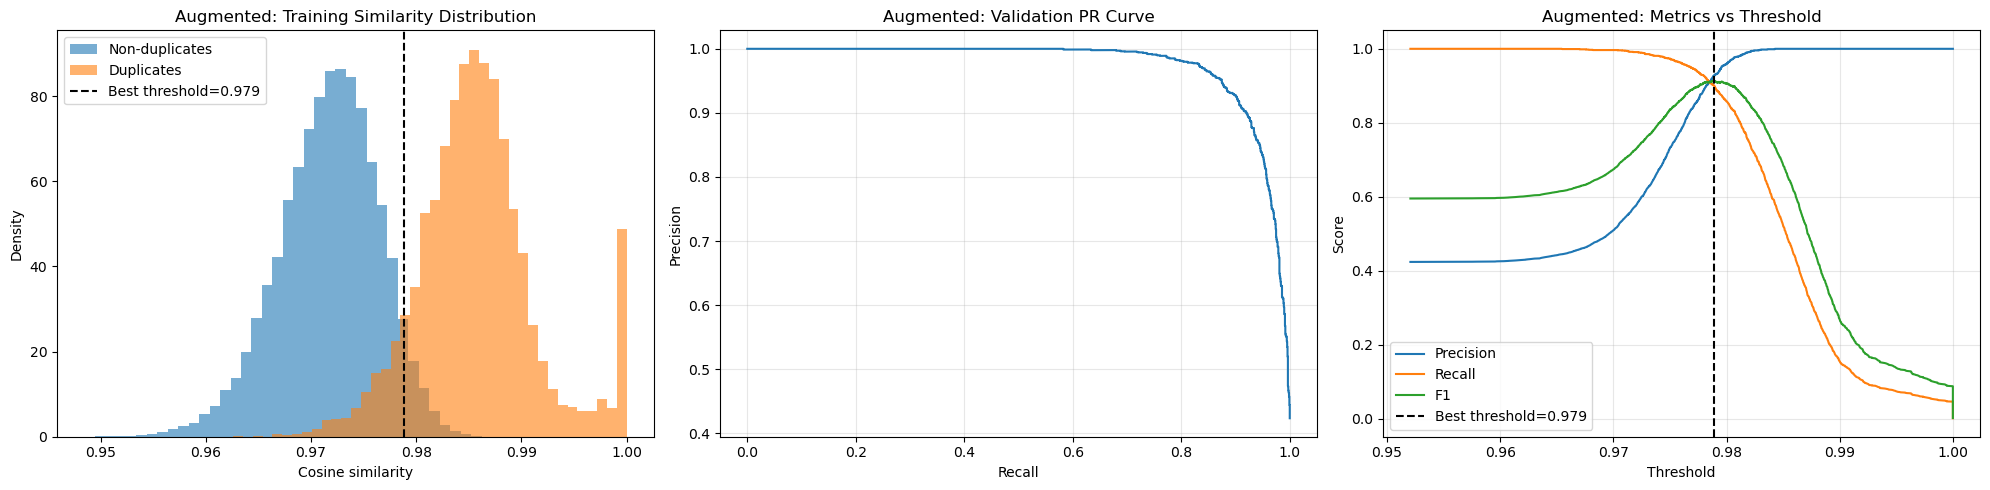

In [201]:
# AUGMENTED TRAINING AND THRESHOLD SELECTION
print('\n' + '=' * 80)
print('AUGMENTED TRAINING / THRESHOLD SELECTION')
print('=' * 80)

model_aug, threshold_aug, diagnostics_aug = train_and_find_threshold(
    ids_data=combined_ids_aug,
    train_pairs=train_pairs_aug,
    val_pairs=val_pairs_aug,
    vocab_size=38
)

print(f'Best augmented threshold: {threshold_aug:.4f}')
plot_training_diagnostics(
    diagnostics_aug,
    'Augmented',
    output_path='augmented_training_diagnostics.png'
 )


In [202]:
# AUGMENTED EVALUATION: FULL AND SUBSET TEST SETS
print('\n' + '=' * 80)
print('AUGMENTED EVALUATION')
print('=' * 80)

result_test1 = evaluate_on_test(
    model=model_aug,
    ids_data=combined_ids_aug,
    test_pairs=test_pairs_aug,
    threshold=threshold_aug,
    data_name='Augmented',
    test_name='Total Dataset'
)

result_test2 = evaluate_on_test(
    model=model_aug,
    ids_data=combined_ids_aug,
    test_pairs=test_pairs_aug_subset,
    threshold=threshold_aug,
    data_name='Augmented',
    test_name='Subset (Last Names Differ)'
)

print(f"Full test precision: {result_test1['precision']:.4f}")
print(f"Full test recall: {result_test1['recall']:.4f}")
print(f"Full test F1: {result_test1['f1']:.4f}")
print(f"Full test PR AUC: {result_test1['pr_auc']:.4f}")
print(f"Subset test precision: {result_test2['precision']:.4f}")
print(f"Subset test recall: {result_test2['recall']:.4f}")
print(f"Subset test F1: {result_test2['f1']:.4f}")
print(f"Subset test PR AUC: {result_test2['pr_auc']:.4f}")



AUGMENTED EVALUATION
Full test precision: 0.9355
Full test recall: 0.9094
Full test F1: 0.9223
Full test PR AUC: 0.9790
Subset test precision: 0.6456
Subset test recall: 0.7873
Subset test F1: 0.7095
Subset test PR AUC: 0.8192



NON-AUGMENTED TRAINING / THRESHOLD SELECTION
Best non-augmented threshold: 0.9761
Saved plot to non_augmented_training_diagnostics.png


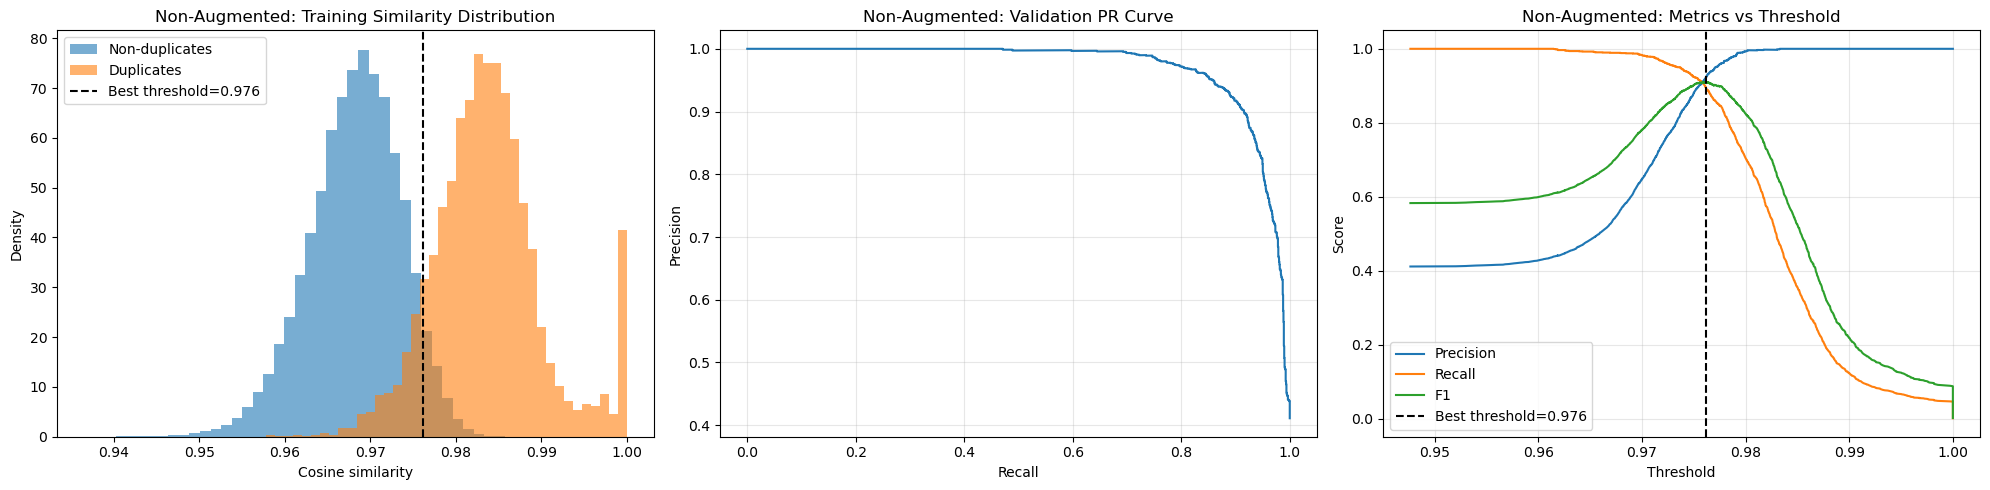

In [203]:
# NON-AUGMENTED TRAINING AND THRESHOLD SELECTION
print('\n' + '=' * 80)
print('NON-AUGMENTED TRAINING / THRESHOLD SELECTION')
print('=' * 80)

model_noaug, threshold_noaug, diagnostics_noaug = train_and_find_threshold(
    ids_data=combined_ids_noaug,
    train_pairs=train_pairs,
    val_pairs=val_pairs,
    vocab_size=38
)

print(f'Best non-augmented threshold: {threshold_noaug:.4f}')
plot_training_diagnostics(
    diagnostics_noaug,
    'Non-Augmented',
    output_path='non_augmented_training_diagnostics.png'
 )


In [204]:
# NON-AUGMENTED EVALUATION: FULL AND SUBSET TEST SETS
print('\n' + '=' * 80)
print('NON-AUGMENTED EVALUATION')
print('=' * 80)

result_test3 = evaluate_on_test(
    model=model_noaug,
    ids_data=combined_ids_noaug,
    test_pairs=test_pairs,
    threshold=threshold_noaug,
    data_name='Non-Augmented',
    test_name='Total Dataset'
)

result_test4 = evaluate_on_test(
    model=model_noaug,
    ids_data=combined_ids_noaug,
    test_pairs=test_pairs_subset,
    threshold=threshold_noaug,
    data_name='Non-Augmented',
    test_name='Subset (Last Names Differ)'
)

print(f"Full test precision: {result_test3['precision']:.4f}")
print(f"Full test recall: {result_test3['recall']:.4f}")
print(f"Full test F1: {result_test3['f1']:.4f}")
print(f"Full test PR AUC: {result_test3['pr_auc']:.4f}")
print(f"Subset test precision: {result_test4['precision']:.4f}")
print(f"Subset test recall: {result_test4['recall']:.4f}")
print(f"Subset test F1: {result_test4['f1']:.4f}")
print(f"Subset test PR AUC: {result_test4['pr_auc']:.4f}")



NON-AUGMENTED EVALUATION
Full test precision: 0.9123
Full test recall: 0.9009
Full test F1: 0.9066
Full test PR AUC: 0.9701
Subset test precision: 0.5742
Subset test recall: 0.8054
Subset test F1: 0.6704
Subset test PR AUC: 0.8034


In [205]:
# Summary of all 4 evaluations from 2 threshold trainings
print('\n' + '=' * 80)
print('SUMMARY: Baseline Model')
print('=' * 80)

summary_df = pd.DataFrame({
    'Training Regime': [
        'Augmented',
        'Augmented',
        'Non-Augmented',
        'Non-Augmented'
    ],
    'Test Set': [
        'Full',
        'Subset',
        'Full',
        'Subset'
    ],
    'Threshold': [
        result_test1['threshold'],
        result_test2['threshold'],
        result_test3['threshold'],
        result_test4['threshold']
    ],
    'Precision': [
        result_test1['precision'],
        result_test2['precision'],
        result_test3['precision'],
        result_test4['precision']
    ],
    'Recall': [
        result_test1['recall'],
        result_test2['recall'],
        result_test3['recall'],
        result_test4['recall']
    ],
    'F1 Score': [
        result_test1['f1'],
        result_test2['f1'],
        result_test3['f1'],
        result_test4['f1']
    ],
    'PR AUC': [
        result_test1['pr_auc'],
        result_test2['pr_auc'],
        result_test3['pr_auc'],
        result_test4['pr_auc']
    ]
})

print(summary_df.to_string(index=False))



SUMMARY: Baseline Model
Training Regime Test Set  Threshold  Precision   Recall  F1 Score   PR AUC
      Augmented     Full   0.978885   0.935538 0.909449  0.922309 0.979039
      Augmented   Subset   0.978885   0.645640 0.787330  0.709480 0.819155
  Non-Augmented     Full   0.976141   0.912292 0.900919  0.906570 0.970130
  Non-Augmented   Subset   0.976141   0.574194 0.805430  0.670433 0.803410
